# 07A — Random Forest for Road Accident Severity Prediction

This notebook follows the course practical focus on Random Forests, OOB error, bagging, feature subsampling, permutation importance, and Decision Tree comparison.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.inspection import permutation_importance
import joblib
RANDOM_STATE = 42
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
MODEL_DIR = Path("../models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load preprocessed data
Reuse the same train/test split and Information Gain outputs used by the Logistic Regression experiments.


In [3]:
X_train_final = sparse.load_npz(DATA_DIR / "X_train_final.npz").tocsr()
X_test_final = sparse.load_npz(DATA_DIR / "X_test_final.npz").tocsr()
y_train = np.load(DATA_DIR / "y_train_encoded.npy")
y_test = np.load(DATA_DIR / "y_test_encoded.npy")
feature_names = pd.read_csv(DATA_DIR / "final_feature_names.csv").iloc[:,0].astype(str).tolist()
selected_features_df = pd.read_csv(DATA_DIR / "selected_features_ig.csv")
class_names = ["Fatal accident", "Other injury accident", "Serious injury accident"]
print("Training matrix:", X_train_final.shape)
print("Testing matrix :", X_test_final.shape)
print("Selected original features:", len(selected_features_df))


Training matrix: (160278, 361)
Testing matrix : (40070, 361)
Selected original features: 26


## 2. Apply Information Gain feature selection
The selected list contains the 26 original features with IG >= 0.005. One-hot encoded columns belonging to a selected original feature are retained.


In [4]:
selected_original_features = selected_features_df["original_feature"].astype(str).tolist()
selected_encoded_indices = []
selected_encoded_names = []
for original_feature in selected_original_features:
    if original_feature == "ROAD_NAME" and "ROAD_NAME_FREQ" in feature_names:
        matches = [feature_names.index("ROAD_NAME_FREQ")]
    else:
        matches = [i for i,n in enumerate(feature_names) if n == original_feature or n.startswith(original_feature + "_")]
    selected_encoded_indices.extend(matches)
    selected_encoded_names.extend([feature_names[i] for i in matches])
X_train_selected = X_train_final[:, selected_encoded_indices].tocsr()
X_test_selected = X_test_final[:, selected_encoded_indices].tocsr()
print("Reduced training matrix:", X_train_selected.shape)
print("Reduced testing matrix :", X_test_selected.shape)


Reduced training matrix: (160278, 217)
Reduced testing matrix : (40070, 217)


## 3. Random Forest baseline
Random Forest combines bootstrap sampling with random feature selection. `oob_score=True` enables an Out-of-Bag estimate.


In [5]:
rf_model = RandomForestClassifier(n_estimators=100, max_features="sqrt", bootstrap=True, oob_score=True, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_selected, y_train)
print("Training completed.")
print("Trees:", rf_model.n_estimators)
print("OOB score:", round(rf_model.oob_score_, 4))


Training completed.
Trees: 100
OOB score: 0.6429


## 4. Evaluation
Report accuracy and macro-averaged precision, recall, F1 and ROC-AUC, along with the classification report.


In [6]:
def evaluate_model(model, X, y, dataset_name):
    pred = model.predict(X)
    prob = model.predict_proba(X)
    result = {"Dataset": dataset_name, "Accuracy": accuracy_score(y,pred), "Macro Precision": precision_score(y,pred,average="macro",zero_division=0), "Macro Recall": recall_score(y,pred,average="macro",zero_division=0), "Macro F1": f1_score(y,pred,average="macro",zero_division=0), "Macro ROC-AUC": roc_auc_score(y,prob,multi_class="ovr",average="macro")}
    print(f"===== {dataset_name} =====")
    for k,v in result.items():
        if k != "Dataset": print(f"{k}: {v:.4f}")
    print("\nClassification Report:\n", classification_report(y,pred,target_names=class_names,zero_division=0))
    return result, pred
train_metrics, y_train_pred = evaluate_model(rf_model,X_train_selected,y_train,"Training")
test_metrics, y_test_pred = evaluate_model(rf_model,X_test_selected,y_test,"Testing")
rf_results = pd.DataFrame([train_metrics,test_metrics])
display(rf_results.round(4))


===== Training =====
Accuracy: 0.9978
Macro Precision: 0.9985
Macro Recall: 0.9972
Macro F1: 0.9979
Macro ROC-AUC: 1.0000

Classification Report:
                          precision    recall  f1-score   support

         Fatal accident       1.00      1.00      1.00      2682
  Other injury accident       1.00      1.00      1.00     99953
Serious injury accident       1.00      1.00      1.00     57643

               accuracy                           1.00    160278
              macro avg       1.00      1.00      1.00    160278
           weighted avg       1.00      1.00      1.00    160278

===== Testing =====
Accuracy: 0.6507
Macro Precision: 0.4530
Macro Recall: 0.4110
Macro F1: 0.4137
Macro ROC-AUC: 0.7244

Classification Report:
                          precision    recall  f1-score   support

         Fatal accident       0.13      0.02      0.03       670
  Other injury accident       0.70      0.81      0.75     24989
Serious injury accident       0.53      0.41      0.4

,Dataset,Accuracy,Macro Precision,Macro Recall,Macro F1,Macro ROC-AUC
0,Training,0.9978,0.9985,0.9972,0.9979,1.0000
1,Testing,0.6507,0.4530,0.4110,0.4137,0.7244


[[   12   216   442]
 [   33 20202  4754]
 [   47  8503  5861]]


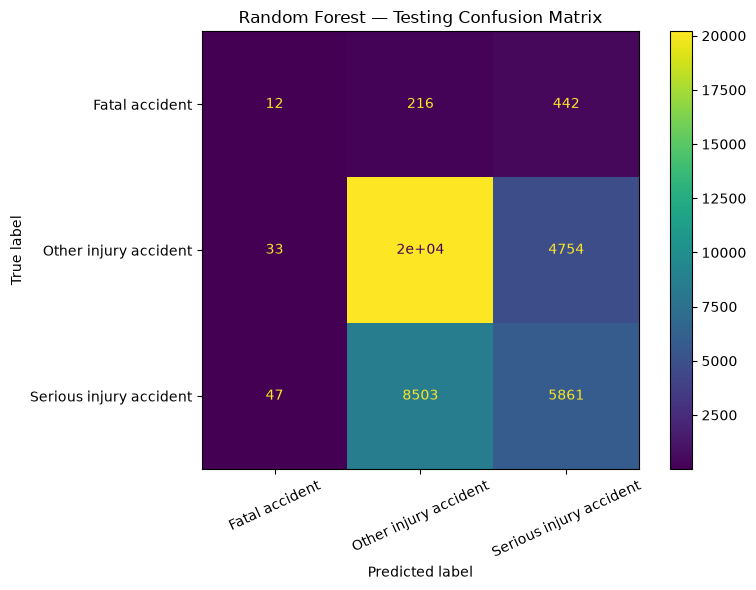

In [7]:
cm = confusion_matrix(y_test,y_test_pred)
print(cm)
fig, ax = plt.subplots(figsize=(8,6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=25)
ax.set_title("Random Forest — Testing Confusion Matrix")
plt.tight_layout(); plt.show()


## 5. OOB score and convergence
OOB observations are samples not selected into a particular tree bootstrap sample. Their aggregated predictions provide an internal estimate.


In [8]:
print("OOB score:", round(rf_model.oob_score_,4))
print("OOB error:", round(1-rf_model.oob_score_,4))
tree_counts=[10,25,50,75,100,150]
oob_model=RandomForestClassifier(n_estimators=10,max_features="sqrt",bootstrap=True,oob_score=True,warm_start=True,random_state=RANDOM_STATE,n_jobs=-1)
records=[]
for n in tree_counts:
    oob_model.set_params(n_estimators=n); oob_model.fit(X_train_selected,y_train); records.append({"n_estimators":n,"oob_score":oob_model.oob_score_})
oob_df=pd.DataFrame(records); oob_df["oob_error"]=1-oob_df["oob_score"]
display(oob_df.round(4))


OOB score: 0.6429
OOB error: 0.3571


c:\Users\Rehan's Lenovo\OneDrive\Desktop\KLH\2-1\ML\github\Road-Accident-Severity-Prediction\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\Rehan's Lenovo\OneDrive\Desktop\KLH\2-1\ML\github\Road-Accident-Severity-Prediction\.MLvenv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,oob_score,oob_error
0,10,0.6068,0.3932
1,25,0.6306,0.3694
2,50,0.6375,0.3625
3,75,0.6417,0.3583
4,100,0.6429,0.3571
5,150,0.6448,0.3552


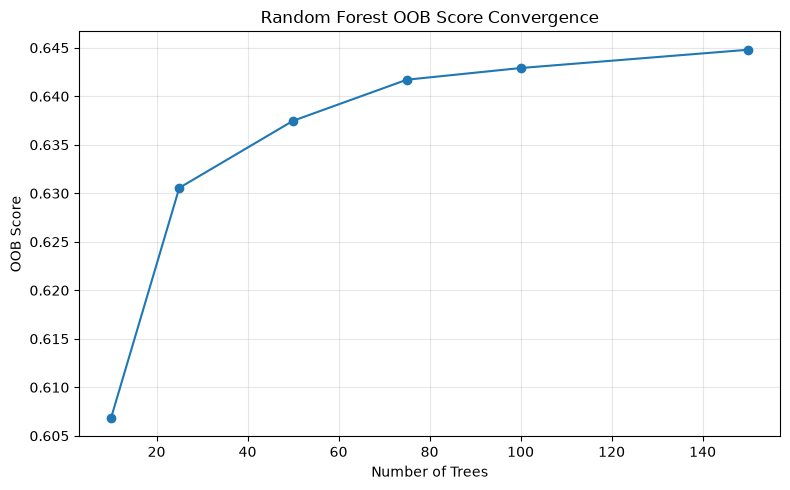

In [9]:
plt.figure(figsize=(8,5)); plt.plot(oob_df["n_estimators"],oob_df["oob_score"],marker="o"); plt.xlabel("Number of Trees"); plt.ylabel("OOB Score"); plt.title("Random Forest OOB Score Convergence"); plt.grid(True,alpha=0.3); plt.tight_layout(); plt.show()


## 6. Feature subsampling — `max_features` comparison
Different settings change the amount of feature-level randomness and therefore tree diversity.


In [10]:
settings=["sqrt","log2",0.5]
rows=[]
for setting in settings:
    m=RandomForestClassifier(n_estimators=100,max_features=setting,bootstrap=True,oob_score=True,random_state=RANDOM_STATE,n_jobs=-1)
    m.fit(X_train_selected,y_train); p=m.predict(X_test_selected); pr=m.predict_proba(X_test_selected)
    rows.append({"max_features":str(setting),"OOB Score":m.oob_score_,"Test Accuracy":accuracy_score(y_test,p),"Test Macro Precision":precision_score(y_test,p,average="macro",zero_division=0),"Test Macro Recall":recall_score(y_test,p,average="macro",zero_division=0),"Test Macro F1":f1_score(y_test,p,average="macro",zero_division=0),"Test Macro ROC-AUC":roc_auc_score(y_test,pr,multi_class="ovr",average="macro")})
max_features_results=pd.DataFrame(rows); display(max_features_results.round(4))


,max_features,OOB Score,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1,Test Macro ROC-AUC
0,sqrt,0.6429,0.6507,0.4530,0.4110,0.4137,0.7244
1,log2,0.6418,0.6494,0.4404,0.4073,0.4084,0.7222
2,0.5,0.6419,0.6466,0.4586,0.4111,0.4144,0.7247


## 7. Bagging demonstration
Bagging uses bootstrap samples and aggregates predictions. Random Forest adds random feature selection at tree splits.


In [11]:
bagging_model=BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),n_estimators=100,max_samples=1.0,bootstrap=True,random_state=RANDOM_STATE,n_jobs=-1)
bagging_model.fit(X_train_selected,y_train)
bp=bagging_model.predict(X_test_selected); bprob=bagging_model.predict_proba(X_test_selected)
bagging_results={"Model":"BaggingClassifier","Test Accuracy":accuracy_score(y_test,bp),"Test Macro Precision":precision_score(y_test,bp,average="macro",zero_division=0),"Test Macro Recall":recall_score(y_test,bp,average="macro",zero_division=0),"Test Macro F1":f1_score(y_test,bp,average="macro",zero_division=0),"Test Macro ROC-AUC":roc_auc_score(y_test,bprob,multi_class="ovr",average="macro")}
display(pd.DataFrame([bagging_results]).round(4))


,Model,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1,Test Macro ROC-AUC
0,BaggingClassifier,0.6442,0.46,0.4118,0.4164,0.7168


## 8. Permutation feature importance
Importance is measured by shuffling a feature and observing the decrease in Macro F1. A reproducible 10,000-row test sample is used to keep computation practical.


In [ ]:
X_perm = X_test_selected[idx].toarray()

perm = permutation_importance(
    rf_model,
    X_perm,
    y_test[idx],
    scoring="f1_macro",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": selected_encoded_names,
    "Importance Mean": perm.importances_mean,
    "Importance Std": perm.importances_std
}).sort_values("Importance Mean", ascending=False)

display(importance_df.head(20).round(6))

InvalidParameterError: The 'X' parameter of permutation_importance must be an array-like. Got <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 270000 stored elements and shape (10000, 217)> instead.

In [ ]:
plot_df=importance_df.head(15).sort_values("Importance Mean")
plt.figure(figsize=(9,7)); plt.barh(plot_df["Feature"],plot_df["Importance Mean"],xerr=plot_df["Importance Std"]); plt.xlabel("Mean decrease in Macro F1"); plt.ylabel("Feature"); plt.title("Random Forest — Permutation Feature Importance"); plt.tight_layout(); plt.show()


## 9. Decision Tree comparison
A single Decision Tree is compared with the ensemble to show the effect of combining many trees.


In [ ]:
dt=DecisionTreeClassifier(random_state=RANDOM_STATE); dt.fit(X_train_selected,y_train); dp=dt.predict(X_test_selected); dprob=dt.predict_proba(X_test_selected)
dt_results={"Model":"Decision Tree","Test Accuracy":accuracy_score(y_test,dp),"Test Macro Precision":precision_score(y_test,dp,average="macro",zero_division=0),"Test Macro Recall":recall_score(y_test,dp,average="macro",zero_division=0),"Test Macro F1":f1_score(y_test,dp,average="macro",zero_division=0),"Test Macro ROC-AUC":roc_auc_score(y_test,dprob,multi_class="ovr",average="macro")}
comparison=pd.DataFrame([{**{"Model":"Random Forest"},**{k:v for k,v in rf_results.iloc[1].to_dict().items() if k!="Dataset"}},bagging_results,dt_results])
display(comparison.round(4))


## 10. Interpretation
Accuracy should not be considered alone because the Fatal class is much smaller than the other severity classes. Macro precision, recall and F1 give each severity class equal weight. The OOB curve and `max_features` table show how ensemble settings affect model behaviour.


## 11. Save outputs


In [ ]:
rf_results.to_csv(OUTPUT_DIR/"random_forest_train_test_results.csv",index=False)
oob_df.to_csv(OUTPUT_DIR/"random_forest_oob_convergence.csv",index=False)
max_features_results.to_csv(OUTPUT_DIR/"random_forest_max_features_comparison.csv",index=False)
comparison.to_csv(OUTPUT_DIR/"random_forest_model_comparison.csv",index=False)
importance_df.to_csv(OUTPUT_DIR/"random_forest_permutation_importance.csv",index=False)
joblib.dump(rf_model,MODEL_DIR/"random_forest_model.joblib")
print("Results and model saved successfully.")


In [ ]:
print("===== FINAL CHECK =====")
print("Train shape:",X_train_selected.shape)
print("Test shape :",X_test_selected.shape)
print("OOB score  :",round(rf_model.oob_score_,4))
print("Test accuracy:",round(test_metrics["Accuracy"],4))
print("Test macro F1:",round(test_metrics["Macro F1"],4))
print("===== COMPLETE =====")
